# Modelo XGBoost — ChicharritAI

Entrenamiento y evaluación del modelo de predicción de outbreaks de *Dalbulus maidis* usando XGBoost con 28 features climáticas y geográficas.

**Split temporal**: Train en temporada 2024-2025, Test en temporada 2025-2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score,
)
from sklearn.inspection import permutation_importance
import shap

sns.set_theme(style="whitegrid", font_scale=1.1)
TARGET_COLORS = {0: "#2ecc71", 1: "#e74c3c"}

df = pd.read_csv("output/dataset.csv")

meta_cols = ["localidad", "provincia", "region", "temporada",
             "max_capturas", "mean_capturas", "n_lecturas", "n_detecciones", "target"]
feature_cols = [c for c in df.columns if c not in meta_cols]

print(f"Dataset: {len(df)} filas, {len(feature_cols)} features")
print(f"Temporadas: {df['temporada'].value_counts().to_dict()}")
print(f"Target: {df['target'].value_counts().to_dict()}")

Dataset: 1045 filas, 36 features
Temporadas: {'2025-2026': 536, '2024-2025': 509}
Target: {1: 663, 0: 382}


/Users/alexanderbodner/Documents/hackitba2026/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Preparación de datos

In [2]:
# 1.1 Features agrupadas por categoría
feature_groups = {
    "Geográficas": ["lat", "lon", "dist_zona_endemica_km"],
    "ENSO": ["oni_invierno"],
    "Invierno - Heladas": ["heladas_count", "heladas_severas_count", "temp_min_abs"],
    "Invierno - Temperatura": ["temp_media_invierno", "temp_min_media_invierno",
                                "dias_tmin_gt_10", "dias_tmin_gt_15", "dias_tmin_gt_18"],
    "Invierno - GDD": ["gdd_base10", "gdd_base0_negativo"],
    "Invierno - Humedad/Precip": ["rh_mean_invierno", "precip_total_invierno", "dias_con_lluvia"],
    "Invierno - Viento": ["wind_mean_invierno", "wind_max_invierno", "wind_norte_ratio"],
    "Primavera": ["temp_media_primavera", "temp_min_media_primavera",
                   "dias_tmin_gt_15_primavera", "dias_tmin_gt_18_primavera",
                   "gdd_base10_primavera", "rh_mean_primavera",
                   "precip_total_primavera", "wind_mean_primavera"],
}

print(f"Total features: {sum(len(v) for v in feature_groups.values())}\n")
for group, cols in feature_groups.items():
    print(f"  {group}: {', '.join(cols)}")

Total features: 28

  Geográficas: lat, lon, dist_zona_endemica_km
  ENSO: oni_invierno
  Invierno - Heladas: heladas_count, heladas_severas_count, temp_min_abs
  Invierno - Temperatura: temp_media_invierno, temp_min_media_invierno, dias_tmin_gt_10, dias_tmin_gt_15, dias_tmin_gt_18
  Invierno - GDD: gdd_base10, gdd_base0_negativo
  Invierno - Humedad/Precip: rh_mean_invierno, precip_total_invierno, dias_con_lluvia
  Invierno - Viento: wind_mean_invierno, wind_max_invierno, wind_norte_ratio
  Primavera: temp_media_primavera, temp_min_media_primavera, dias_tmin_gt_15_primavera, dias_tmin_gt_18_primavera, gdd_base10_primavera, rh_mean_primavera, precip_total_primavera, wind_mean_primavera


In [31]:
# 1.2 Split temporal: Train 2024-2025, Test 2025-2026
X = df[feature_cols]
y = df["target"]

# Rellenar NaN en features de distancia a outbreaks previos (primera temporada no tiene datos previos)
fill_cols = ["dist_nearest_outbreak_km", "dist_nearest_high_outbreak_km"]
for c in fill_cols:
    if c in X.columns:
        X[c] = X[c].fillna(9999.0)

# Verificar que no queden NaN
nan_remaining = X.isna().sum().sum()
if nan_remaining > 0:
    print(f"WARN: {nan_remaining} NaN restantes, eliminando filas afectadas")
    valid = X.notna().all(axis=1)
    df = df[valid].reset_index(drop=True)
    X = df[feature_cols]
    y = df["target"]
    for c in fill_cols:
        if c in X.columns:
            X[c] = X[c].fillna(9999.0)

train_mask = df["temporada"] == "2024-2025"
test_mask = df["temporada"] == "2025-2026"

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train (2024-2025): {len(X_train)} ({y_train.sum()} outbreak, {(y_train==0).sum()} safe)")
print(f"Test  (2025-2026): {len(X_test)} ({y_test.sum()} outbreak, {(y_test==0).sum()} safe)")

Train (2024-2025): 509 (323 outbreak, 186 safe)
Test  (2025-2026): 536 (340 outbreak, 196 safe)


/var/folders/k5/m3vphss513b3ggz7lzrn75440000gn/T/ipykernel_34064/1031999589.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[c] = X[c].fillna(9999.0)


## 2. Baseline — Regresión Logística
Entrenamos una regresión logística como baseline para comparar contra XGBoost. Usamos estandarización de features y el mismo split temporal.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score

# Pipeline: estandarizar + regresión logística con class_weight balanceado
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=1.0,
        solver="lbfgs",
        random_state=42,
    ))
])

lr_pipeline.fit(X_train, y_train)

# Predicciones
lr_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba > 0.5).astype(int)

lr_auc = roc_auc_score(y_test, lr_proba)
lr_ap = average_precision_score(y_test, lr_proba)
lr_f1 = f1_score(y_test, lr_pred, zero_division=0)

print(f"Logistic Regression Baseline")
print(f"  ROC AUC:           {lr_auc:.3f}")
print(f"  Average Precision: {lr_ap:.3f}")
print(f"  F1:                {lr_f1:.3f}")
print(f"\n{classification_report(y_test, lr_pred, target_names=['Safe', 'Outbreak'], zero_division=0)}")

Logistic Regression Baseline
  ROC AUC:           0.758
  Average Precision: 0.826
  F1:                0.821

              precision    recall  f1-score   support

        Safe       0.84      0.34      0.48       196
    Outbreak       0.72      0.96      0.82       340

    accuracy                           0.73       536
   macro avg       0.78      0.65      0.65       536
weighted avg       0.76      0.73      0.70       536



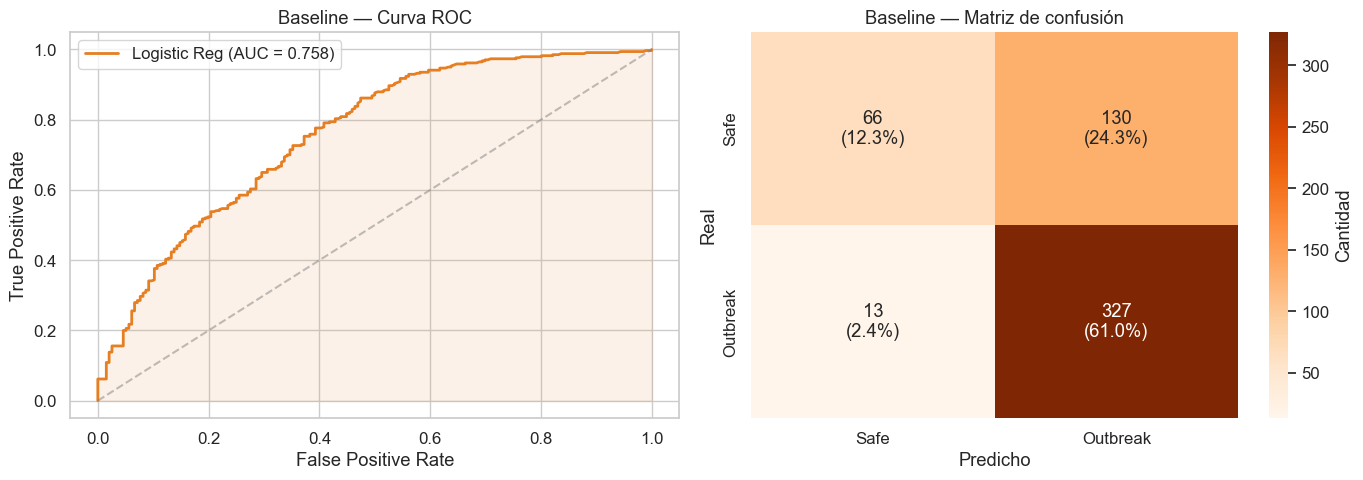

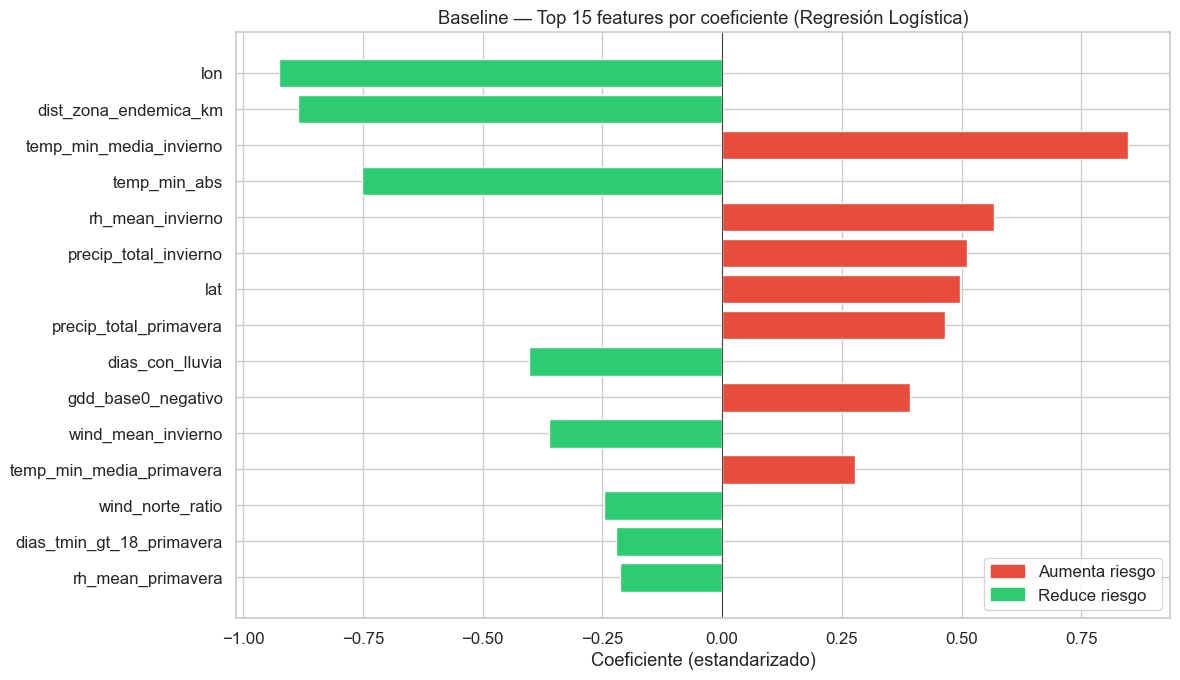

In [33]:
# Baseline: Curva ROC + Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
axes[0].plot(fpr_lr, tpr_lr, linewidth=2, color="#e67e22", label=f"Logistic Reg (AUC = {lr_auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.5)
axes[0].fill_between(fpr_lr, tpr_lr, alpha=0.1, color="#e67e22")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Baseline — Curva ROC")
axes[0].legend(fontsize=12)

# Confusion Matrix
cm_lr = confusion_matrix(y_test, lr_pred)
labels_lr = np.array([[f"{v}\n({v/cm_lr.sum()*100:.1f}%)" for v in row] for row in cm_lr])
sns.heatmap(cm_lr, annot=labels_lr, fmt="", cmap="Oranges", ax=axes[1],
            xticklabels=["Safe", "Outbreak"], yticklabels=["Safe", "Outbreak"],
            cbar_kws={"label": "Cantidad"})
axes[1].set_xlabel("Predicho")
axes[1].set_ylabel("Real")
axes[1].set_title("Baseline — Matriz de confusión")

plt.tight_layout()
plt.show()

# Coeficientes del modelo (top 15 por valor absoluto)
lr_model = lr_pipeline.named_steps["lr"]
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coef": lr_model.coef_[0],
    "abs_coef": np.abs(lr_model.coef_[0]),
}).sort_values("abs_coef", ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ["#e74c3c" if c > 0 else "#2ecc71" for c in coef_df["coef"]]
ax.barh(coef_df["feature"], coef_df["coef"], color=colors, edgecolor="white")
ax.set_xlabel("Coeficiente (estandarizado)")
ax.set_title("Baseline — Top 15 features por coeficiente (Regresión Logística)")
ax.axvline(0, color="black", linewidth=0.5)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e74c3c", label="Aumenta riesgo"),
                    Patch(color="#2ecc71", label="Reduce riesgo")], loc="lower right")
plt.tight_layout()
plt.show()

## 3. Entrenamiento XGBoost

In [34]:
# 2.1 Configuración y entrenamiento
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale = n_neg / n_pos if n_pos > 0 else 1.0

model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=1.0,
    scale_pos_weight=scale,
    eval_metric="logloss",
    random_state=42,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False,
)
print("Modelo entrenado.")

Modelo entrenado.


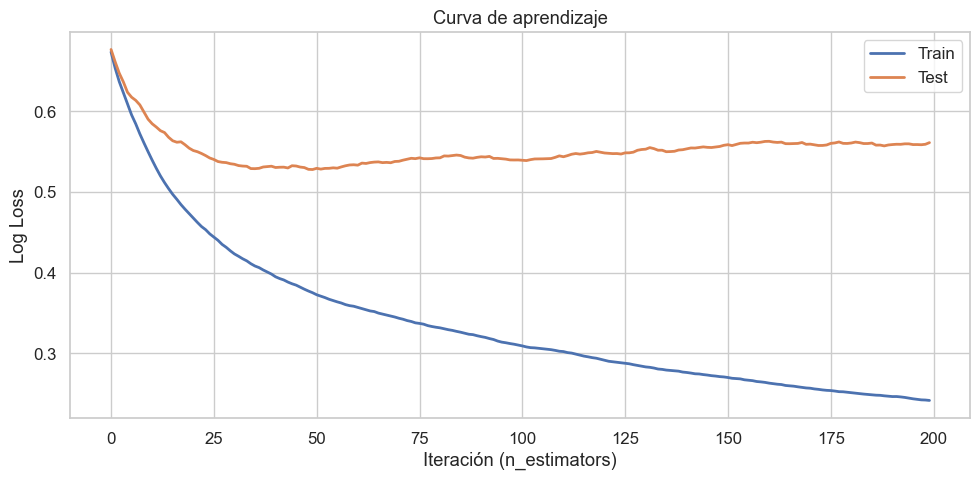

In [35]:
# 2.2 Curva de aprendizaje (training loss)
results = model.evals_result()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(results["validation_0"]["logloss"], label="Train", linewidth=2)
ax.plot(results["validation_1"]["logloss"], label="Test", linewidth=2)
ax.set_xlabel("Iteración (n_estimators)")
ax.set_ylabel("Log Loss")
ax.set_title("Curva de aprendizaje")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Evaluación

In [36]:
# Predicciones
DECISION_THRESHOLD = 0.3  # Optimizado para mejor recall en regiones lejanas

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > DECISION_THRESHOLD).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)
print(f"ROC AUC: {auc:.3f}")
print(f"Average Precision: {ap:.3f}")
print(f"Umbral de decisión: {DECISION_THRESHOLD}")
print(f"\n{classification_report(y_test, y_pred, target_names=['Safe', 'Outbreak'], zero_division=0)}")

ROC AUC: 0.804
Average Precision: 0.857
Umbral de decisión: 0.3

              precision    recall  f1-score   support

        Safe       0.77      0.58      0.66       196
    Outbreak       0.79      0.90      0.84       340

    accuracy                           0.78       536
   macro avg       0.78      0.74      0.75       536
weighted avg       0.78      0.78      0.78       536



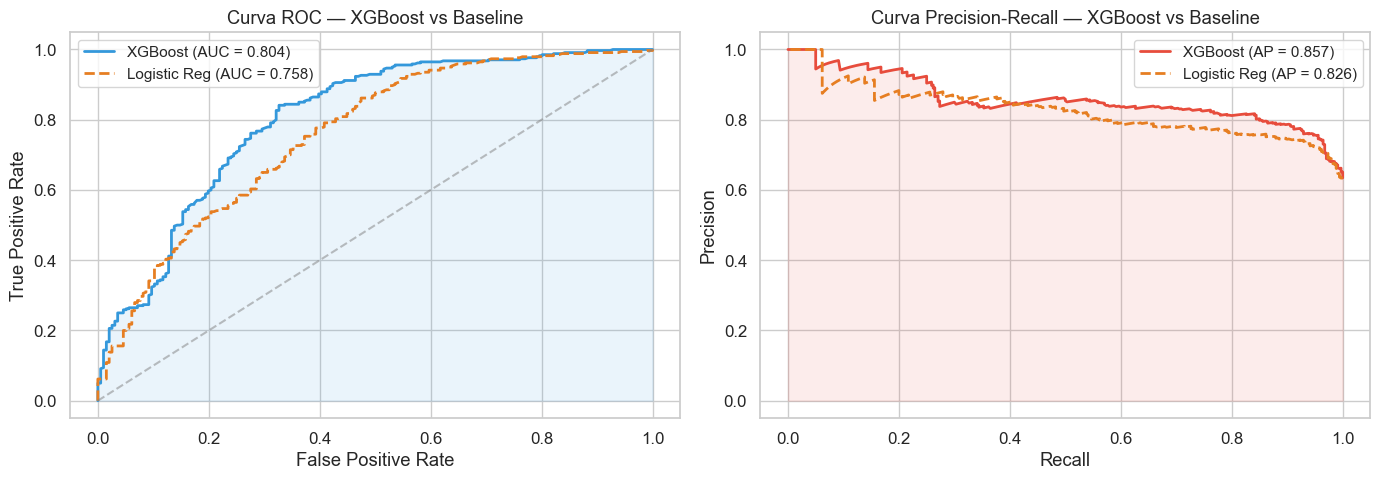

In [37]:
# 4.1 Curva ROC + Precision-Recall (XGBoost vs Baseline)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC — ambos modelos
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, linewidth=2, color="#3498db", label=f"XGBoost (AUC = {auc:.3f})")
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
axes[0].plot(fpr_lr, tpr_lr, linewidth=2, color="#e67e22", linestyle="--", label=f"Logistic Reg (AUC = {lr_auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.5)
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#3498db")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Curva ROC — XGBoost vs Baseline")
axes[0].legend(fontsize=11)

# Precision-Recall — ambos modelos
prec, rec, _ = precision_recall_curve(y_test, y_pred_proba)
prec_lr, rec_lr, _ = precision_recall_curve(y_test, lr_proba)
axes[1].plot(rec, prec, linewidth=2, color="#e74c3c", label=f"XGBoost (AP = {ap:.3f})")
axes[1].plot(rec_lr, prec_lr, linewidth=2, color="#e67e22", linestyle="--", label=f"Logistic Reg (AP = {lr_ap:.3f})")
axes[1].fill_between(rec, prec, alpha=0.1, color="#e74c3c")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall — XGBoost vs Baseline")
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

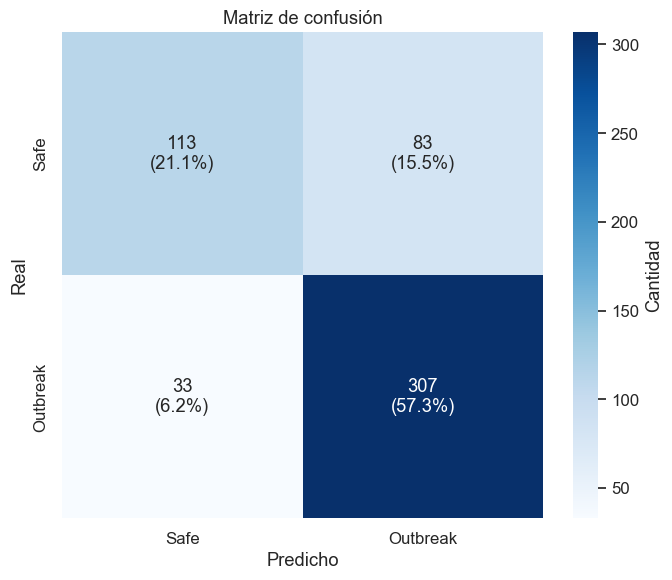

In [38]:
# 3.2 Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
labels = np.array([[f"{v}\n({v/cm.sum()*100:.1f}%)" for v in row] for row in cm])
sns.heatmap(cm, annot=labels, fmt="", cmap="Blues", ax=ax,
            xticklabels=["Safe", "Outbreak"], yticklabels=["Safe", "Outbreak"],
            cbar_kws={"label": "Cantidad"})
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión")
plt.tight_layout()
plt.show()

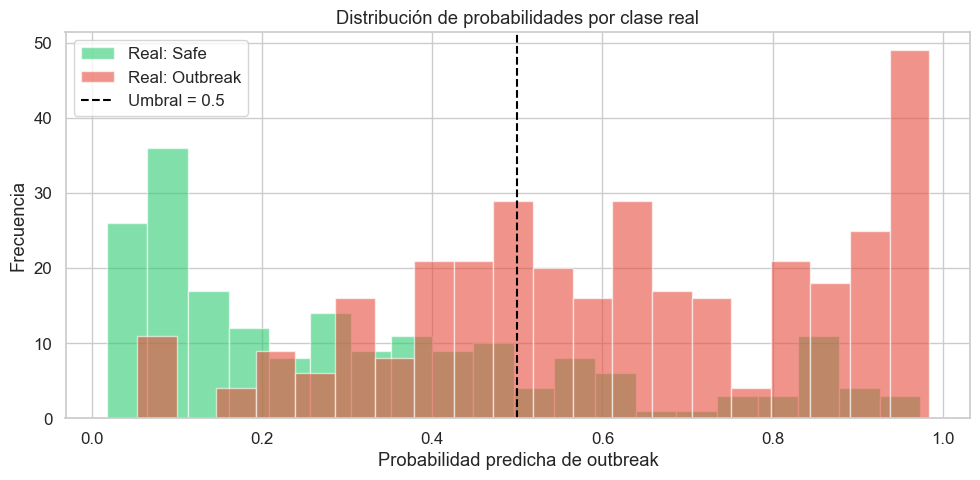

In [39]:
# 3.3 Distribución de probabilidades predichas por clase real
fig, ax = plt.subplots(figsize=(10, 5))
for t, color, label in [(0, TARGET_COLORS[0], "Safe"), (1, TARGET_COLORS[1], "Outbreak")]:
    mask = y_test == t
    ax.hist(y_pred_proba[mask], bins=20, alpha=0.6, color=color, label=f"Real: {label}", edgecolor="white")
ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1.5, label="Umbral = 0.5")
ax.set_xlabel("Probabilidad predicha de outbreak")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de probabilidades por clase real")
ax.legend()
plt.tight_layout()
plt.show()

In [40]:
# 4.4 Tabla comparativa: Baseline vs XGBoost
xgb_f1 = f1_score(y_test, y_pred, zero_division=0)

comparison = pd.DataFrame([
    {
        "Modelo": "Logistic Regression (baseline)",
        "ROC AUC": lr_auc,
        "Avg Precision": lr_ap,
        "F1": lr_f1,
        "Precision": classification_report(y_test, lr_pred, output_dict=True, zero_division=0)["1"]["precision"],
        "Recall": classification_report(y_test, lr_pred, output_dict=True, zero_division=0)["1"]["recall"],
    },
    {
        "Modelo": f"XGBoost (threshold={DECISION_THRESHOLD})",
        "ROC AUC": auc,
        "Avg Precision": ap,
        "F1": xgb_f1,
        "Precision": classification_report(y_test, y_pred, output_dict=True, zero_division=0)["1"]["precision"],
        "Recall": classification_report(y_test, y_pred, output_dict=True, zero_division=0)["1"]["recall"],
    },
])

delta_auc = auc - lr_auc
delta_ap = ap - lr_ap
delta_f1 = xgb_f1 - lr_f1

print("═" * 60)
print("COMPARACIÓN: Baseline vs XGBoost")
print("═" * 60)
display(comparison.round(3))
print(f"\nMejora XGBoost sobre baseline:")
print(f"  ΔAUC:  {delta_auc:+.3f}")
print(f"  ΔAP:   {delta_ap:+.3f}")
print(f"  ΔF1:   {delta_f1:+.3f}")

════════════════════════════════════════════════════════════
COMPARACIÓN: Baseline vs XGBoost
════════════════════════════════════════════════════════════


,Modelo,ROC AUC,Avg Precision,F1,Precision,Recall
0,Logistic Regression (baseline),0.758,0.826,0.821,0.716,0.962
1,XGBoost (threshold=0.3),0.804,0.857,0.841,0.787,0.903



Mejora XGBoost sobre baseline:
  ΔAUC:  +0.046
  ΔAP:   +0.030
  ΔF1:   +0.021


## 4. Feature Importance

In [41]:
# Mapping de features a categorías para colorear
def get_feature_category(feat):
    for group, cols in feature_groups.items():
        if feat in cols:
            return group
    return "Otro"

category_colors = {
    "Geográficas": "#e74c3c",
    "ENSO": "#9b59b6",
    "Invierno - Heladas": "#3498db",
    "Invierno - Temperatura": "#2980b9",
    "Invierno - GDD": "#1abc9c",
    "Invierno - Humedad/Precip": "#16a085",
    "Invierno - Viento": "#27ae60",
    "Primavera": "#f39c12",
}

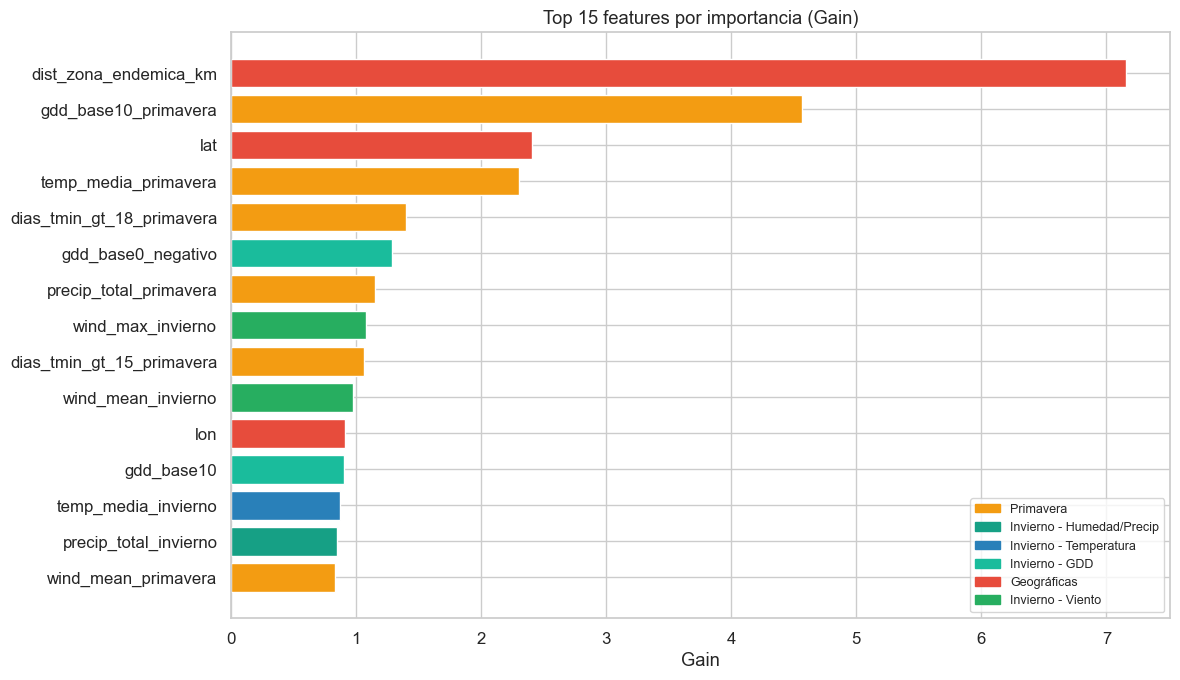

In [42]:
# 4.1 Importancia por ganancia (top 15)
gain = model.get_booster().get_score(importance_type="gain")
gain_df = pd.DataFrame({"feature": gain.keys(), "gain": gain.values()})
gain_df = gain_df.sort_values("gain", ascending=True).tail(15)
gain_df["category"] = gain_df["feature"].apply(get_feature_category)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [category_colors.get(c, "gray") for c in gain_df["category"]]
ax.barh(gain_df["feature"], gain_df["gain"], color=colors, edgecolor="white")
ax.set_xlabel("Gain")
ax.set_title("Top 15 features por importancia (Gain)")

# Leyenda
from matplotlib.patches import Patch
used_cats = gain_df["category"].unique()
handles = [Patch(color=category_colors[c], label=c) for c in used_cats if c in category_colors]
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

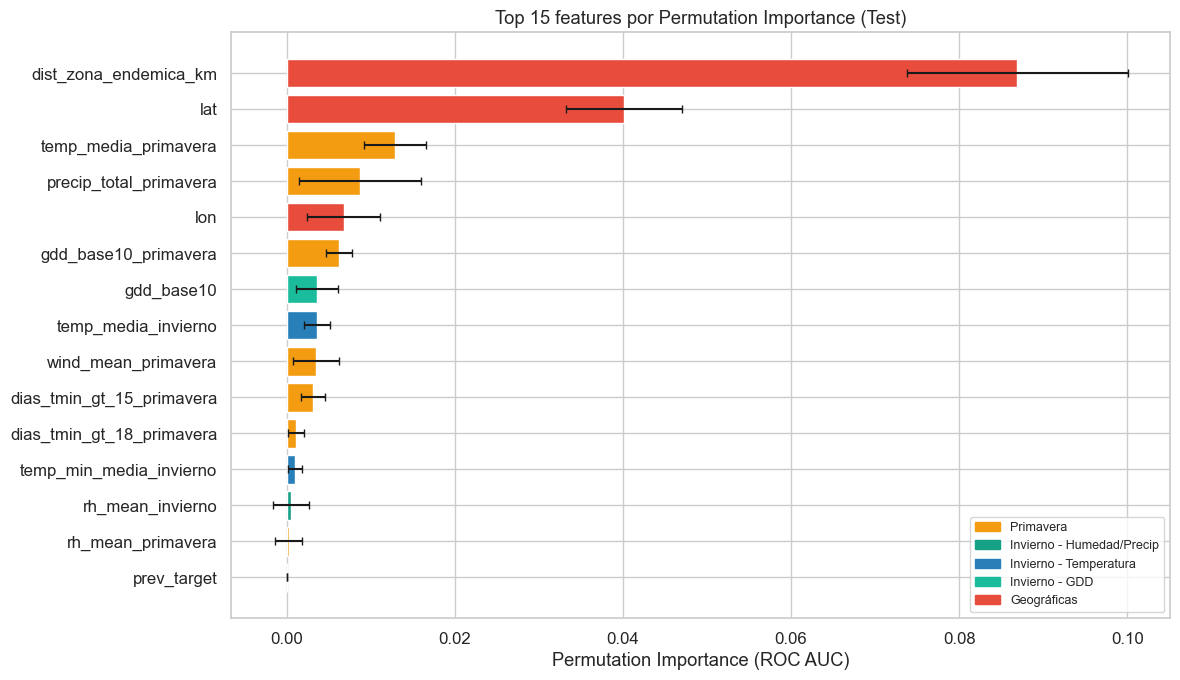

In [43]:
# 4.2 Permutation importance (test set)
perm = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42, scoring="roc_auc")
perm_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=True).tail(15)
perm_df["category"] = perm_df["feature"].apply(get_feature_category)

fig, ax = plt.subplots(figsize=(12, 7))
colors = [category_colors.get(c, "gray") for c in perm_df["category"]]
ax.barh(perm_df["feature"], perm_df["importance"], xerr=perm_df["std"],
        color=colors, edgecolor="white", capsize=3)
ax.set_xlabel("Permutation Importance (ROC AUC)")
ax.set_title("Top 15 features por Permutation Importance (Test)")

used_cats = perm_df["category"].unique()
handles = [Patch(color=category_colors[c], label=c) for c in used_cats if c in category_colors]
ax.legend(handles=handles, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 5. SHAP — Explicabilidad del modelo

In [44]:
# Calcular SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

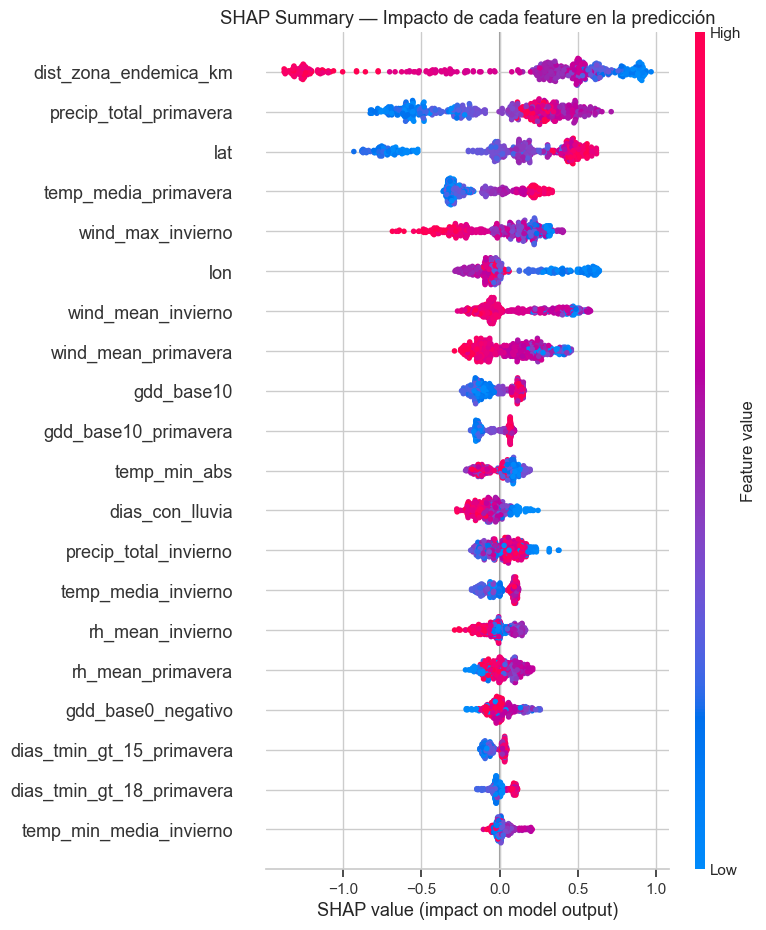

In [45]:
# 5.1 SHAP Summary plot (beeswarm)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary — Impacto de cada feature en la predicción")
plt.tight_layout()
plt.show()

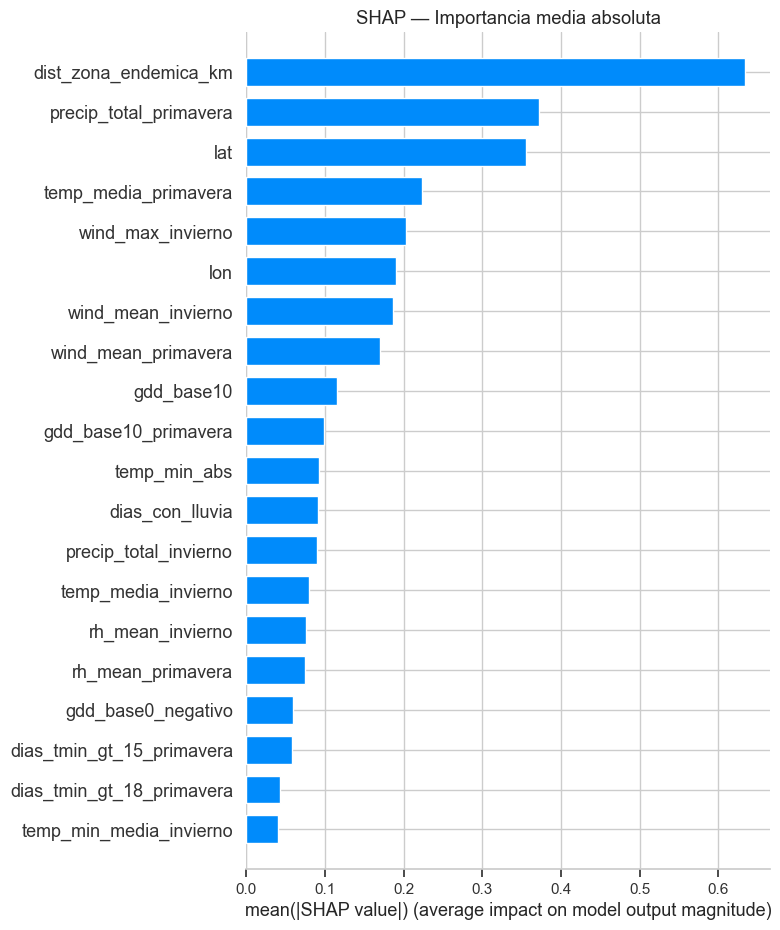

In [46]:
# 5.2 SHAP Bar plot (importancia media absoluta)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP — Importancia media absoluta")
plt.tight_layout()
plt.show()

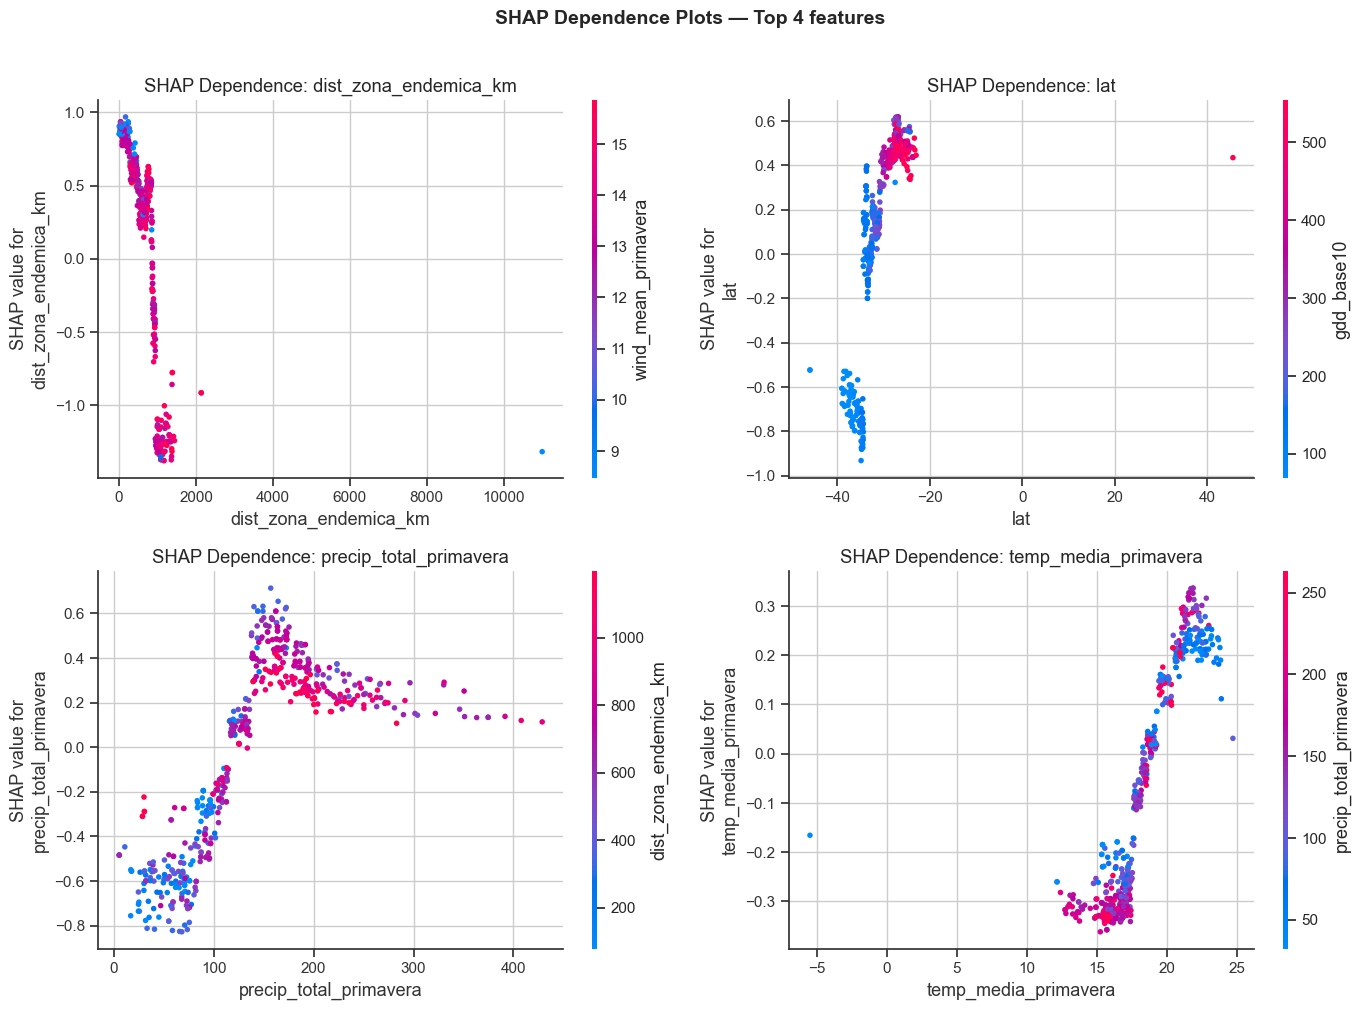

In [47]:
# 5.3 SHAP Dependence plots — top 4 features
top_feats = ["dist_zona_endemica_km", "lat", "precip_total_primavera", "temp_media_primavera"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, feat in zip(axes.flat, top_feats):
    shap.dependence_plot(feat, shap_values, X_test, ax=ax, show=False)
    ax.set_title(f"SHAP Dependence: {feat}")

plt.suptitle("SHAP Dependence Plots — Top 4 features", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

Ejemplo: índice 244, probabilidad = 0.984, real = 1


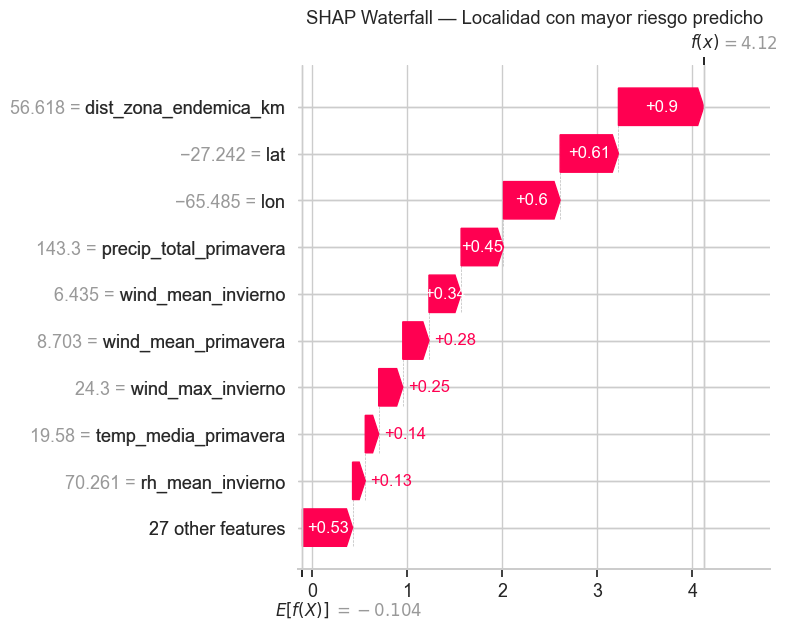

In [48]:
# 5.4 SHAP Waterfall — ejemplo de localidad con alto riesgo
high_risk_idx = y_pred_proba.argmax()
print(f"Ejemplo: índice {high_risk_idx}, probabilidad = {y_pred_proba[high_risk_idx]:.3f}, real = {y_test.iloc[high_risk_idx]}")

shap_explanation = shap.Explanation(
    values=shap_values[high_risk_idx],
    base_values=explainer.expected_value,
    data=X_test.iloc[high_risk_idx],
    feature_names=feature_cols,
)
plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, show=False)
plt.title("SHAP Waterfall — Localidad con mayor riesgo predicho")
plt.tight_layout()
plt.show()

## 6. Análisis por región y mapa de riesgo

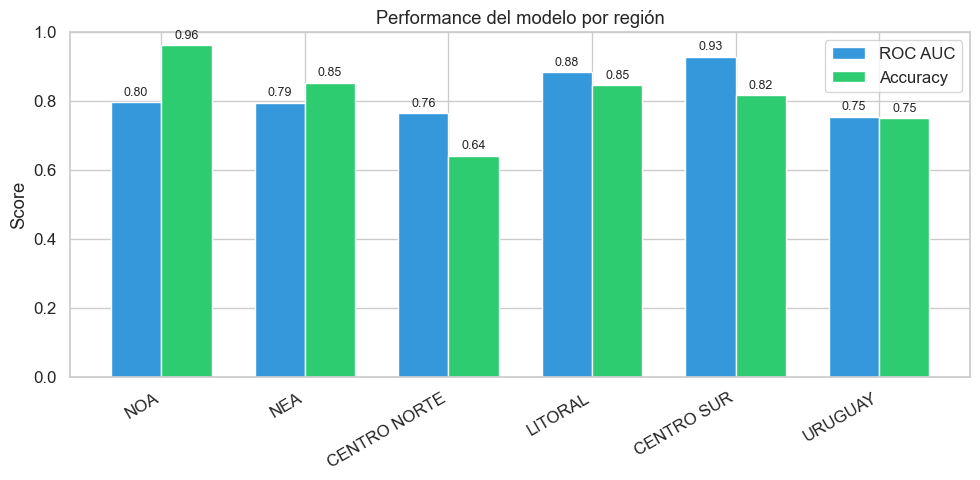

In [21]:
# 6.1 Predicción sobre todo el dataset + métricas por región
df["pred_proba"] = model.predict_proba(df[feature_cols])[:, 1]
df["pred"] = (df["pred_proba"] > 0.5).astype(int)

region_metrics = []
for region in ["NOA", "NEA", "CENTRO NORTE", "LITORAL", "CENTRO SUR", "URUGUAY"]:
    mask = df["region"] == region
    sub = df[mask]
    if len(sub) < 5 or sub["target"].nunique() < 2:
        continue
    auc_r = roc_auc_score(sub["target"], sub["pred_proba"])
    acc_r = (sub["pred"] == sub["target"]).mean()
    region_metrics.append({"Región": region, "N": len(sub), "AUC": auc_r, "Accuracy": acc_r})

rm_df = pd.DataFrame(region_metrics)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rm_df))
width = 0.35
bars1 = ax.bar(x - width/2, rm_df["AUC"], width, label="ROC AUC", color="#3498db")
bars2 = ax.bar(x + width/2, rm_df["Accuracy"], width, label="Accuracy", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(rm_df["Región"], rotation=30, ha="right")
ax.set_ylabel("Score")
ax.set_title("Performance del modelo por región")
ax.legend()
ax.set_ylim(0, 1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.2f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

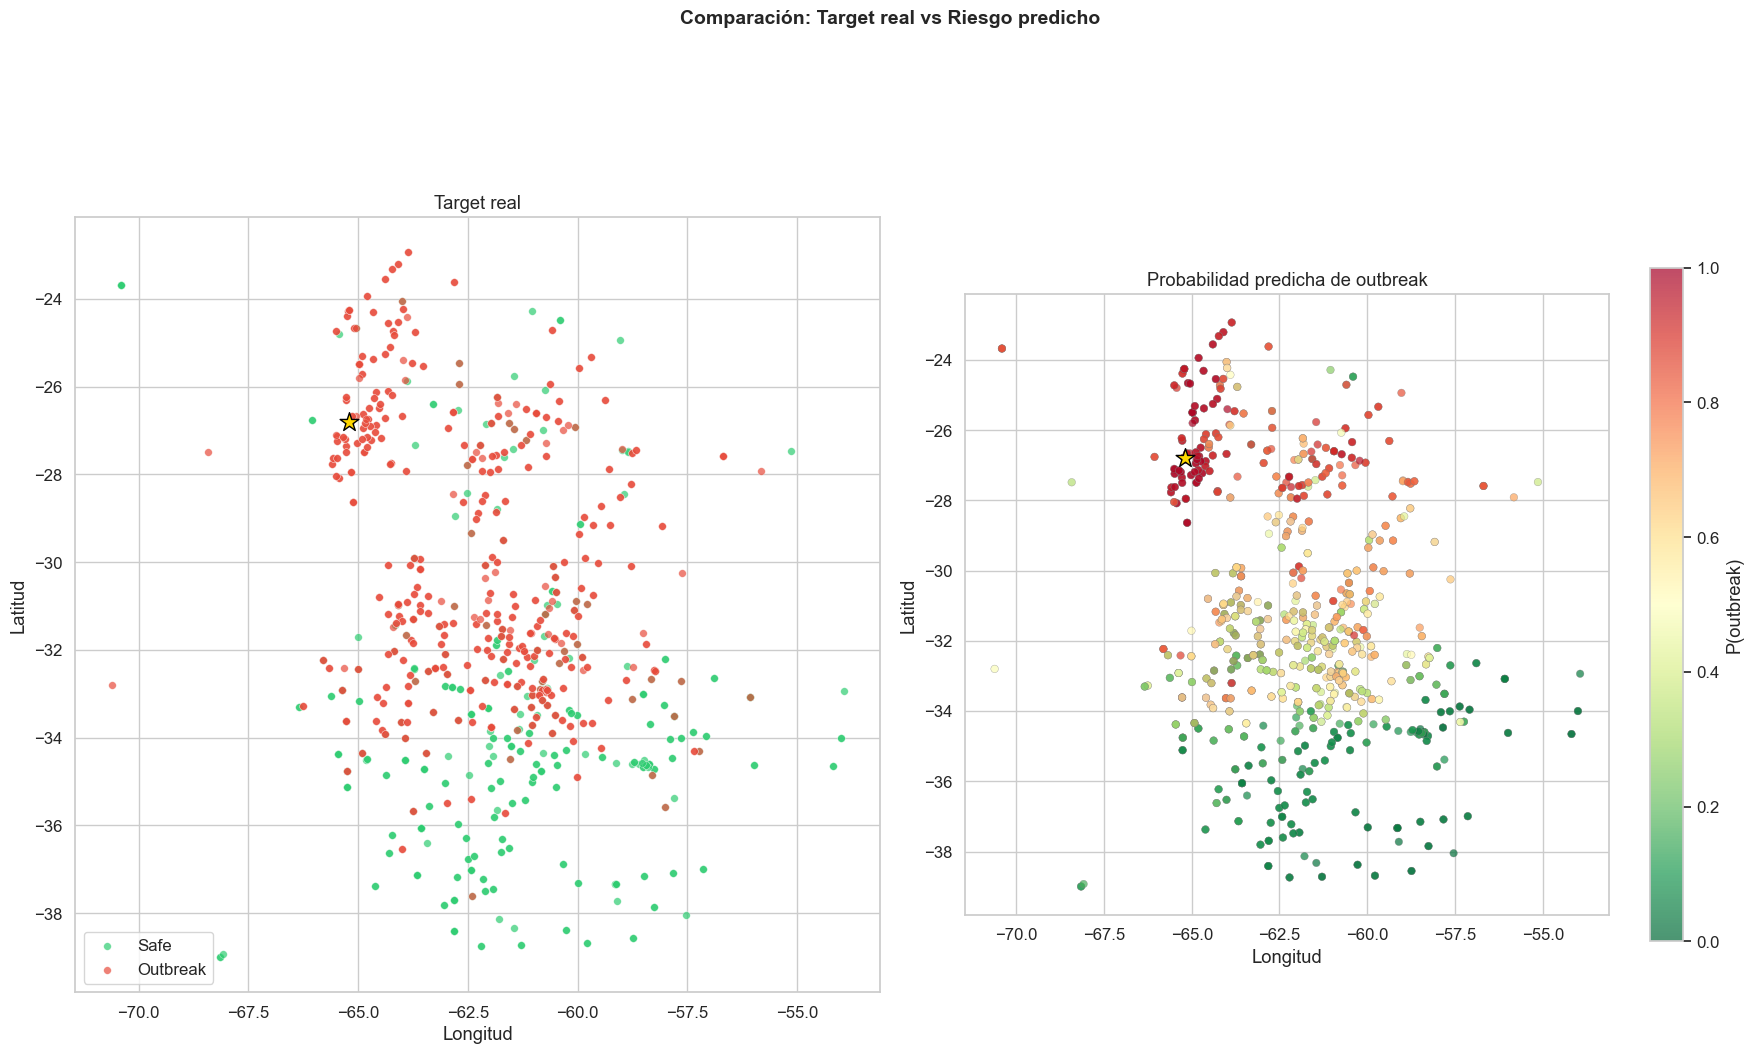

In [22]:
# 6.2 Mapa de riesgo predicho vs real
df_geo = df[(df["lat"] > -45) & (df["lat"] < -20) & (df["lon"] > -75) & (df["lon"] < -53)]

fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# Real
for t in [0, 1]:
    mask = df_geo["target"] == t
    color = TARGET_COLORS[t]
    label = "Safe" if t == 0 else "Outbreak"
    axes[0].scatter(df_geo.loc[mask, "lon"], df_geo.loc[mask, "lat"],
                     c=color, label=label, s=30, alpha=0.7, edgecolors="white", linewidth=0.3)
axes[0].scatter(-65.2, -26.8, c="gold", marker="*", s=200, zorder=5, edgecolors="black")
axes[0].set_title("Target real")
axes[0].legend(loc="lower left")
axes[0].set_aspect("equal")

# Predicho
sc = axes[1].scatter(
    df_geo["lon"], df_geo["lat"],
    c=df_geo["pred_proba"], cmap="RdYlGn_r", s=30,
    alpha=0.7, edgecolors="gray", linewidth=0.3, vmin=0, vmax=1,
)
axes[1].scatter(-65.2, -26.8, c="gold", marker="*", s=200, zorder=5, edgecolors="black")
axes[1].set_title("Probabilidad predicha de outbreak")
axes[1].set_aspect("equal")
plt.colorbar(sc, ax=axes[1], shrink=0.6, label="P(outbreak)")

for ax in axes:
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")

plt.suptitle("Comparación: Target real vs Riesgo predicho", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Análisis detallado por región

In [23]:
# 7.1 Tabla resumen de predicciones por región (solo test = 2025-2026)
test_df = df[test_mask].copy()
test_df["pred_proba"] = y_pred_proba
test_df["pred"] = y_pred

REGIONS = ["NOA", "NEA", "CENTRO NORTE", "LITORAL", "CENTRO SUR", "URUGUAY"]
rows = []
for region in REGIONS:
    sub = test_df[test_df["region"] == region]
    if len(sub) < 3:
        continue
    tp = ((sub["pred"] == 1) & (sub["target"] == 1)).sum()
    fp = ((sub["pred"] == 1) & (sub["target"] == 0)).sum()
    fn = ((sub["pred"] == 0) & (sub["target"] == 1)).sum()
    tn = ((sub["pred"] == 0) & (sub["target"] == 0)).sum()
    auc_r = roc_auc_score(sub["target"], sub["pred_proba"]) if sub["target"].nunique() > 1 else None
    rows.append({
        "Región": region,
        "N": len(sub),
        "Outbreak real": sub["target"].sum(),
        "Outbreak pred": sub["pred"].sum(),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "Recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "AUC": auc_r,
    })

region_table = pd.DataFrame(rows)
print("Predicciones en TEST (temporada 2025-2026) por región:\n")
display(region_table.round(2))

Predicciones en TEST (temporada 2025-2026) por región:



,Región,N,Outbreak real,Outbreak pred,TP,FP,FN,TN,Precision,Recall,AUC
0,NOA,79,75,79,75,4,0,0,0.95,1.00,0.69
1,NEA,92,78,92,78,14,0,0,0.85,1.00,0.47
2,CENTRO NORTE,90,78,80,71,9,7,3,0.89,0.91,0.55
3,LITORAL,37,31,33,30,3,1,3,0.91,0.97,0.77
4,CENTRO SUR,157,65,63,47,16,18,76,0.75,0.72,0.86
5,URUGUAY,26,9,10,3,7,6,10,0.30,0.33,0.42


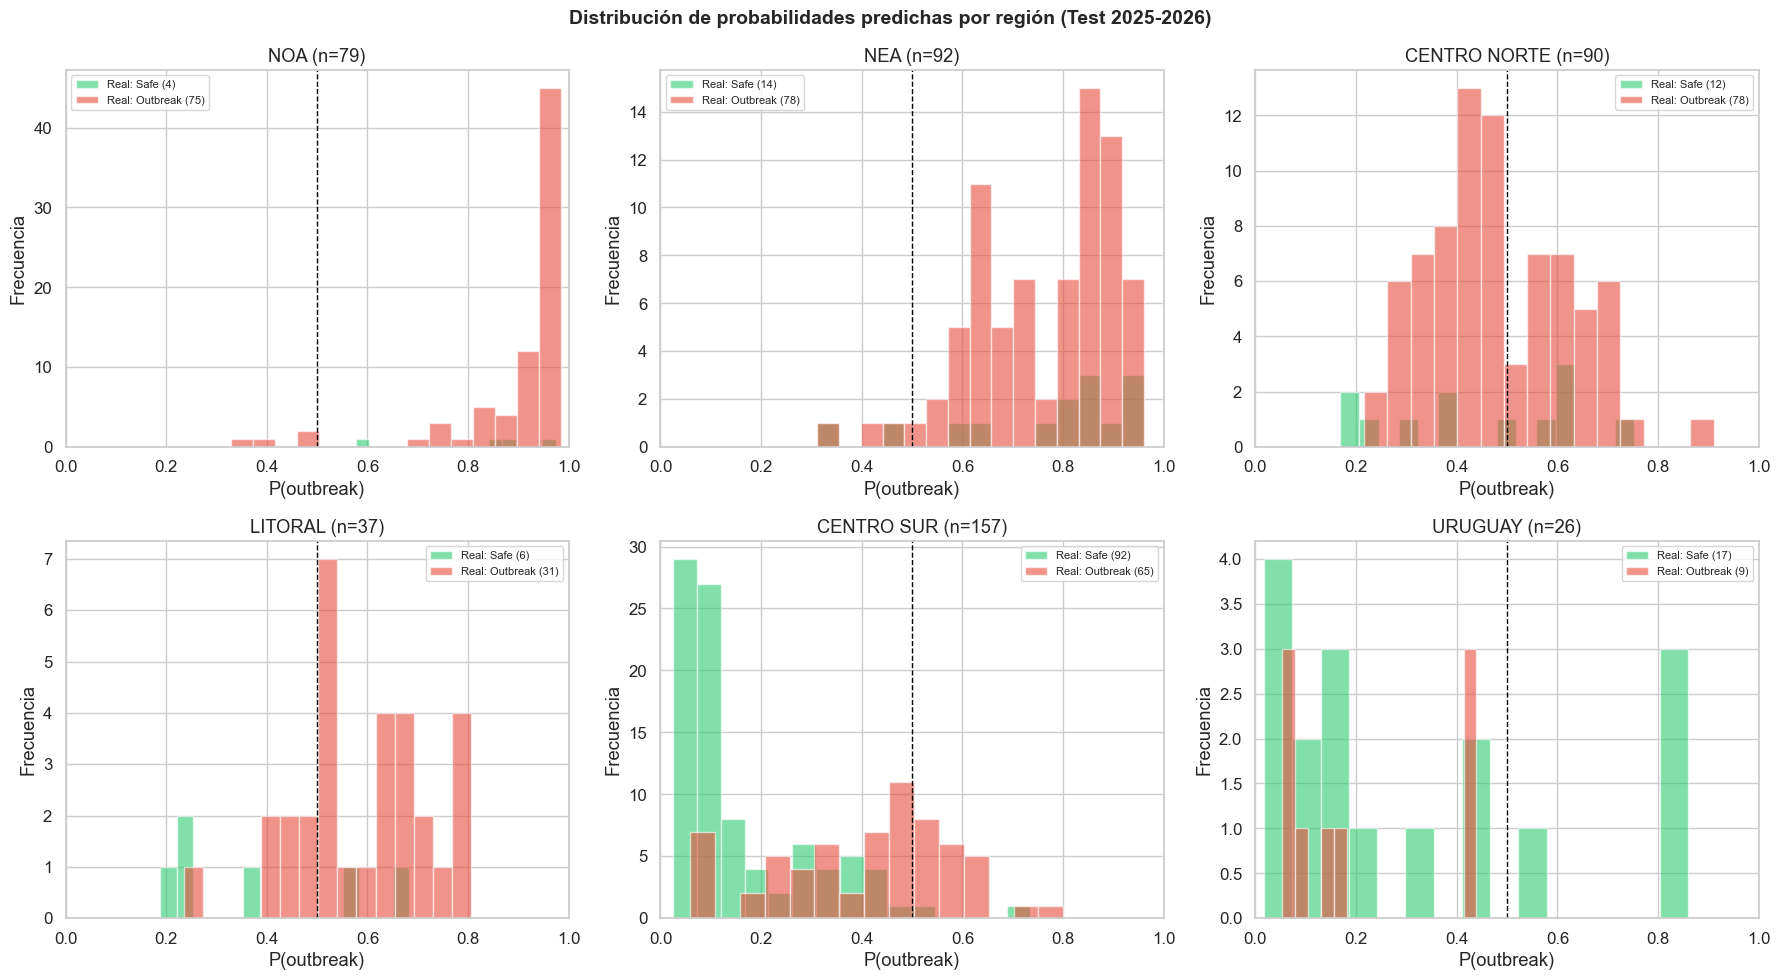

In [24]:
# 7.2 Distribución de probabilidad predicha por región
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, region in zip(axes.flat, REGIONS):
    sub = test_df[test_df["region"] == region]
    if len(sub) < 3:
        ax.set_visible(False)
        continue
    for t, color, label in [(0, TARGET_COLORS[0], "Safe"), (1, TARGET_COLORS[1], "Outbreak")]:
        mask = sub["target"] == t
        if mask.sum() > 0:
            ax.hist(sub.loc[mask, "pred_proba"], bins=15, alpha=0.6, color=color,
                    label=f"Real: {label} ({mask.sum()})", edgecolor="white")
    ax.axvline(x=0.5, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{region} (n={len(sub)})")
    ax.set_xlabel("P(outbreak)")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.suptitle("Distribución de probabilidades predichas por región (Test 2025-2026)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

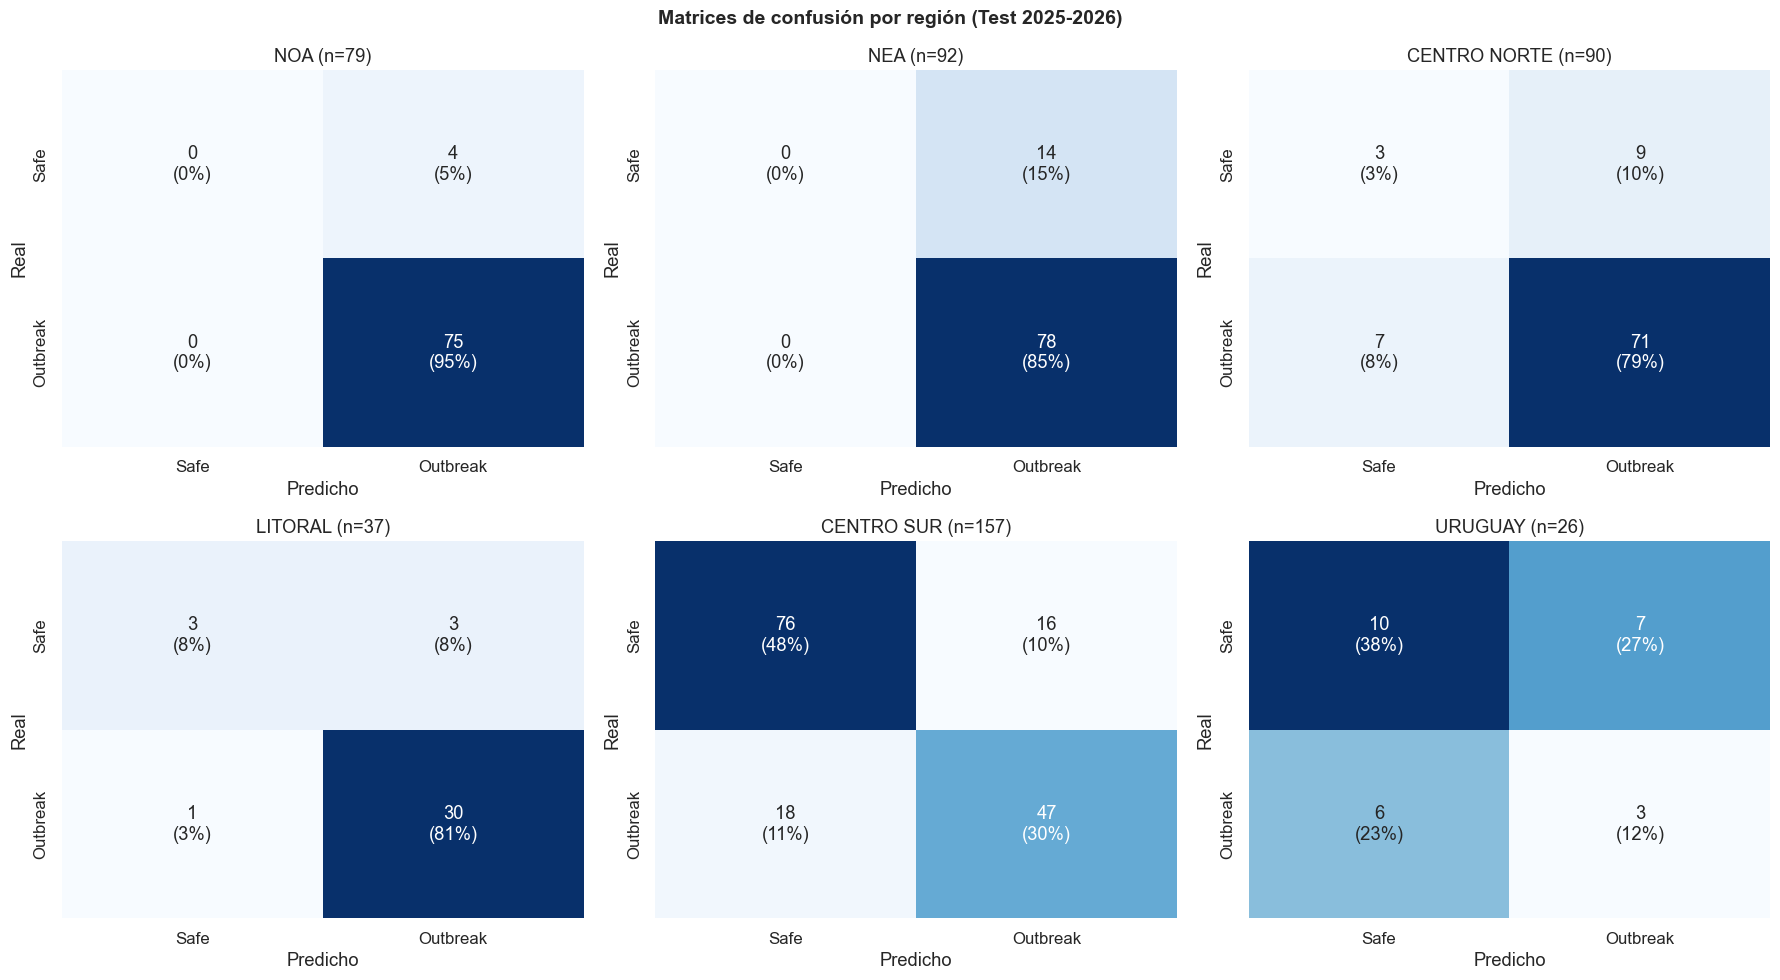

In [25]:
# 7.3 Matriz de confusión por región
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, region in zip(axes.flat, REGIONS):
    sub = test_df[test_df["region"] == region]
    if len(sub) < 3:
        ax.set_visible(False)
        continue
    cm = confusion_matrix(sub["target"], sub["pred"], labels=[0, 1])
    total = cm.sum()
    labels_cm = np.array([[f"{v}\n({v/total*100:.0f}%)" if total > 0 else f"{v}" for v in row] for row in cm])
    sns.heatmap(cm, annot=labels_cm, fmt="", cmap="Blues", ax=ax,
                xticklabels=["Safe", "Outbreak"], yticklabels=["Safe", "Outbreak"],
                cbar=False)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(f"{region} (n={len(sub)})")

plt.suptitle("Matrices de confusión por región (Test 2025-2026)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Análisis de threshold: ¿cuántas capturas definen "riesgo"?

El target actual usa **≥5 adultos/trampa** como umbral de outbreak. Exploramos si este umbral es adecuado y cómo cambia el modelo con distintos thresholds.

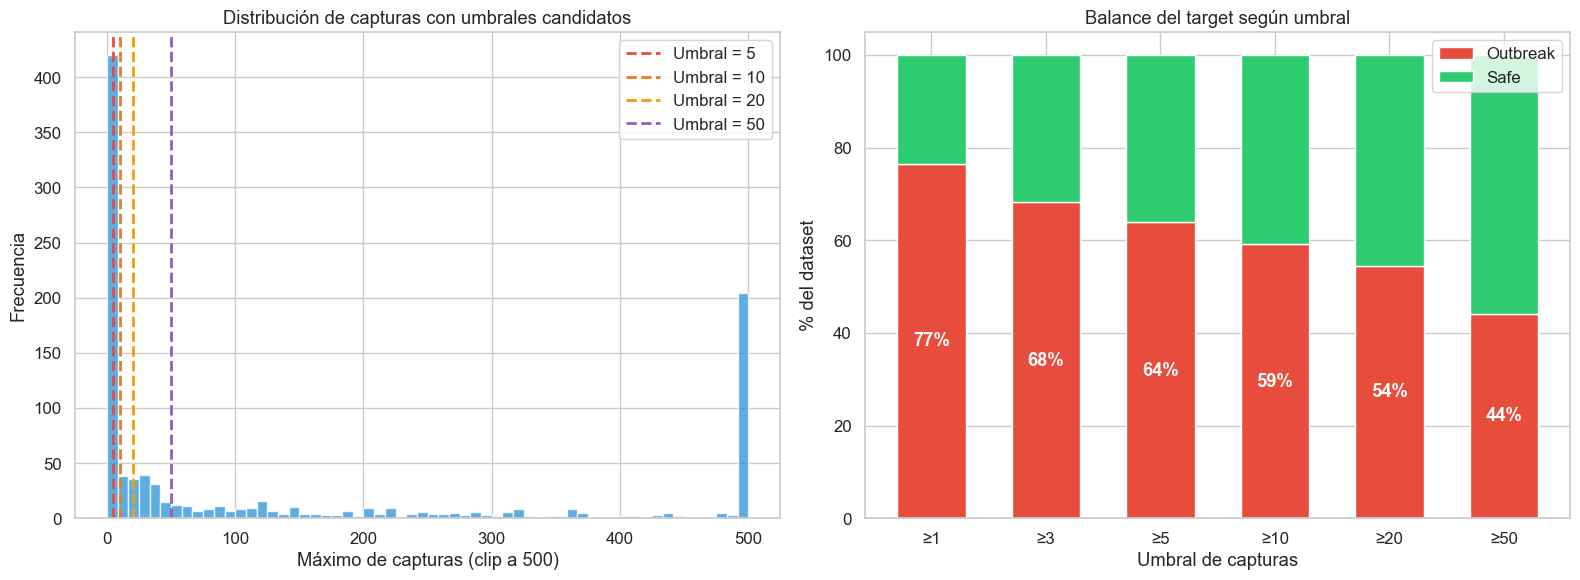

In [26]:
# 8.1 Distribución de capturas máximas con distintos umbrales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma con umbrales marcados
capturas = df["max_capturas"].dropna()
axes[0].hist(capturas.clip(upper=500), bins=60, color="#3498db", edgecolor="white", alpha=0.8)
thresholds = [5, 10, 20, 50]
colors_th = ["#e74c3c", "#e67e22", "#f39c12", "#9b59b6"]
for th, c in zip(thresholds, colors_th):
    axes[0].axvline(x=th, color=c, linestyle="--", linewidth=2, label=f"Umbral = {th}")
axes[0].set_xlabel("Máximo de capturas (clip a 500)")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de capturas con umbrales candidatos")
axes[0].legend()

# Balance del target con cada umbral
thresholds_full = [1, 3, 5, 10, 20, 50]
pct_outbreak = [(capturas >= th).mean() * 100 for th in thresholds_full]
pct_safe = [100 - p for p in pct_outbreak]

x = np.arange(len(thresholds_full))
bars1 = axes[1].bar(x, pct_outbreak, color="#e74c3c", label="Outbreak", width=0.6)
bars2 = axes[1].bar(x, pct_safe, bottom=pct_outbreak, color="#2ecc71", label="Safe", width=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"≥{th}" for th in thresholds_full])
axes[1].set_xlabel("Umbral de capturas")
axes[1].set_ylabel("% del dataset")
axes[1].set_title("Balance del target según umbral")
axes[1].legend()

for bar, pct in zip(bars1, pct_outbreak):
    axes[1].text(bar.get_x() + bar.get_width()/2, pct/2, f"{pct:.0f}%",
                 ha="center", va="center", fontweight="bold", color="white")

plt.tight_layout()
plt.show()

In [27]:
# 8.2 Performance del modelo re-entrenado con distintos umbrales de captura
from sklearn.metrics import f1_score

capture_thresholds = [3, 5, 10, 20, 50]
results_th = []

for th in capture_thresholds:
    y_th = (df["max_capturas"] >= th).astype(int)
    y_train_th = y_th[train_mask]
    y_test_th = y_th[test_mask]

    n_pos_th = y_train_th.sum()
    n_neg_th = len(y_train_th) - n_pos_th
    spw = n_neg_th / n_pos_th if n_pos_th > 0 else 1.0

    m = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.7, reg_alpha=1.0, reg_lambda=1.0,
        scale_pos_weight=spw, eval_metric="logloss", random_state=42)
    m.fit(X_train, y_train_th, verbose=False)

    proba = m.predict_proba(X_test)[:, 1]
    pred = (proba > 0.5).astype(int)

    auc_th = roc_auc_score(y_test_th, proba) if y_test_th.nunique() > 1 else None
    f1_th = f1_score(y_test_th, pred, zero_division=0)
    prec_th = (pred & y_test_th.values).sum() / pred.sum() if pred.sum() > 0 else 0
    rec_th = (pred & y_test_th.values).sum() / y_test_th.sum() if y_test_th.sum() > 0 else 0

    results_th.append({
        "Umbral capturas": f"≥{th}",
        "% outbreak (train)": f"{y_train_th.mean()*100:.0f}%",
        "% outbreak (test)": f"{y_test_th.mean()*100:.0f}%",
        "AUC": auc_th,
        "Precision": prec_th,
        "Recall": rec_th,
        "F1": f1_th,
    })

results_df = pd.DataFrame(results_th)
print("Performance del modelo con distintos umbrales de captura:\n")
display(results_df.round(3))

Performance del modelo con distintos umbrales de captura:



,Umbral capturas,% outbreak (train),% outbreak (test),AUC,Precision,Recall,F1
0,≥3,67%,68%,0.780,0.852,0.694,0.765
1,≥5,63%,63%,0.804,0.839,0.659,0.738
2,≥10,59%,58%,0.824,0.815,0.661,0.730
3,≥20,55%,53%,0.802,0.749,0.694,0.720
4,≥50,44%,44%,0.832,0.709,0.709,0.709


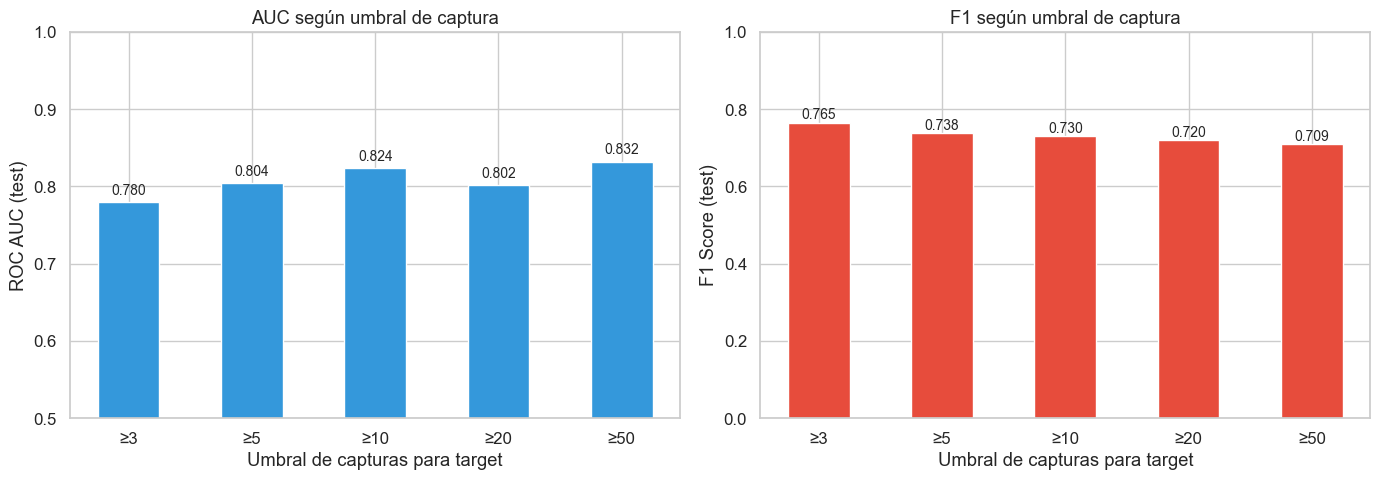

In [28]:
# 8.3 AUC y F1 por umbral de captura (gráfico)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(capture_thresholds))
labels = [f"≥{th}" for th in capture_thresholds]

# AUC
aucs = [r["AUC"] for r in results_th]
bars = axes[0].bar(x, aucs, color="#3498db", width=0.5, edgecolor="white")
for bar, val in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=10)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel("Umbral de capturas para target")
axes[0].set_ylabel("ROC AUC (test)")
axes[0].set_title("AUC según umbral de captura")
axes[0].set_ylim(0.5, 1.0)

# F1
f1s = [r["F1"] for r in results_th]
bars = axes[1].bar(x, f1s, color="#e74c3c", width=0.5, edgecolor="white")
for bar, val in zip(bars, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", fontsize=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel("Umbral de capturas para target")
axes[1].set_ylabel("F1 Score (test)")
axes[1].set_title("F1 según umbral de captura")
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

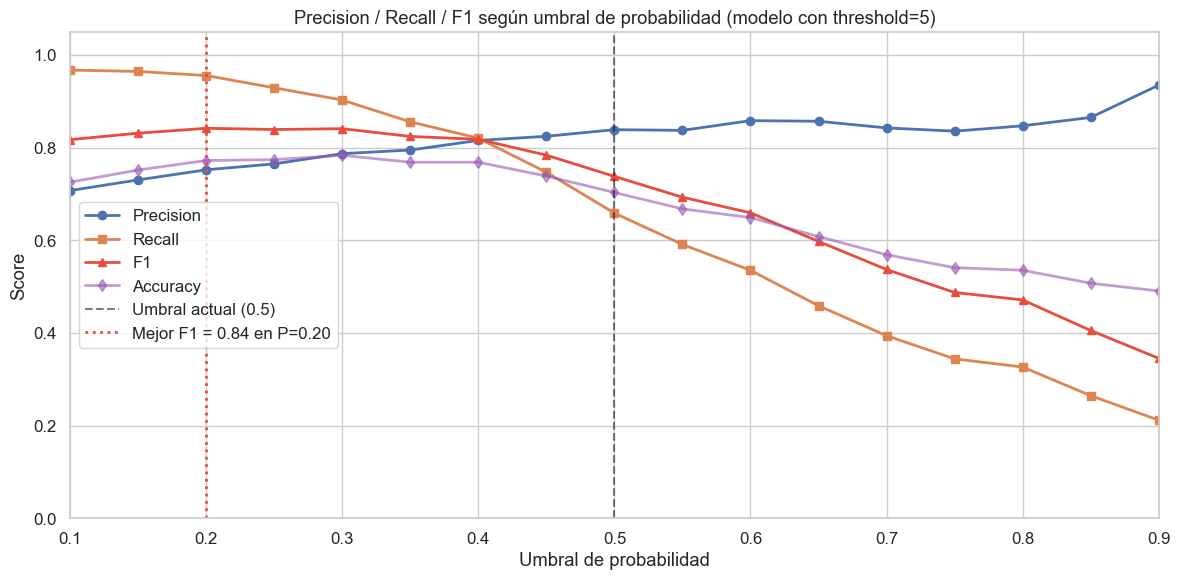

Mejor F1 (0.842) con umbral de probabilidad = 0.20
  Precision: 0.752, Recall: 0.956, Accuracy: 0.772


In [29]:
# 8.4 Análisis del umbral de decisión (probabilidad) — con el modelo actual (threshold=5)
# ¿Qué pasa si en vez de 0.5 usamos otro corte de probabilidad?

prob_thresholds = np.arange(0.1, 0.91, 0.05)
prec_list, rec_list, f1_list, acc_list = [], [], [], []

for pt in prob_thresholds:
    pred_pt = (y_pred_proba >= pt).astype(int)
    tp = ((pred_pt == 1) & (y_test.values == 1)).sum()
    fp = ((pred_pt == 1) & (y_test.values == 0)).sum()
    fn = ((pred_pt == 0) & (y_test.values == 1)).sum()
    tn = ((pred_pt == 0) & (y_test.values == 0)).sum()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    acc = (tp + tn) / (tp + fp + fn + tn)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    acc_list.append(acc)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(prob_thresholds, prec_list, "o-", label="Precision", linewidth=2)
ax.plot(prob_thresholds, rec_list, "s-", label="Recall", linewidth=2)
ax.plot(prob_thresholds, f1_list, "^-", label="F1", linewidth=2, color="#e74c3c")
ax.plot(prob_thresholds, acc_list, "d-", label="Accuracy", linewidth=2, color="#9b59b6", alpha=0.6)
ax.axvline(x=0.5, color="black", linestyle="--", alpha=0.5, label="Umbral actual (0.5)")

best_f1_idx = np.argmax(f1_list)
best_pt = prob_thresholds[best_f1_idx]
ax.axvline(x=best_pt, color="#e74c3c", linestyle=":", linewidth=2,
           label=f"Mejor F1 = {f1_list[best_f1_idx]:.2f} en P={best_pt:.2f}")

ax.set_xlabel("Umbral de probabilidad")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 según umbral de probabilidad (modelo con threshold=5)")
ax.legend(loc="center left")
ax.set_xlim(0.1, 0.9)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"Mejor F1 ({f1_list[best_f1_idx]:.3f}) con umbral de probabilidad = {best_pt:.2f}")
print(f"  Precision: {prec_list[best_f1_idx]:.3f}, Recall: {rec_list[best_f1_idx]:.3f}, Accuracy: {acc_list[best_f1_idx]:.3f}")

## 9. Tabla final comparativa de modelos

In [58]:
# ═══════════════════════════════════════════════════════════════════════
# 9.1 Tabla final comparativa — todos los modelos evaluados
# ═══════════════════════════════════════════════════════════════════════

from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# --- Función auxiliar para métricas ---
def compute_metrics(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    auc = roc_auc_score(y_true, y_proba) if y_true.nunique() > 1 else None
    ap = average_precision_score(y_true, y_proba)
    return {
        "ROC AUC": auc,
        "Avg Precision": ap,
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
    }

rows_final = []

# 1) Logistic Regression baseline (P=0.5)
m_lr = compute_metrics(y_test, lr_proba, threshold=0.5)
rows_final.append({"Modelo": "Logistic Regression", "Umbral capturas": "≥5",
                    "Umbral prob.": 0.50, **m_lr})

# 2) XGBoost con umbral por defecto (P=0.5)
m_xgb50 = compute_metrics(y_test, y_pred_proba, threshold=0.5)
rows_final.append({"Modelo": "XGBoost", "Umbral capturas": "≥5",
                    "Umbral prob.": 0.50, **m_xgb50})

# 3) XGBoost con umbral optimizado (P=0.3)
m_xgb30 = compute_metrics(y_test, y_pred_proba, threshold=DECISION_THRESHOLD)
rows_final.append({"Modelo": "XGBoost (opt.)", "Umbral capturas": "≥5",
                    "Umbral prob.": DECISION_THRESHOLD, **m_xgb30})

# 4) XGBoost con mejor F1 encontrado en análisis de threshold
m_xgb_best = compute_metrics(y_test, y_pred_proba, threshold=best_pt)
rows_final.append({"Modelo": f"XGBoost (best F1)", "Umbral capturas": "≥5",
                    "Umbral prob.": round(best_pt, 2), **m_xgb_best})

# 5) XGBoost re-entrenado con distintos umbrales de captura
for th_info in results_th:
    rows_final.append({
        "Modelo": "XGBoost",
        "Umbral capturas": th_info["Umbral capturas"],
        "Umbral prob.": 0.50,
        "ROC AUC": th_info["AUC"],
        "Avg Precision": None,
        "Precision": th_info["Precision"],
        "Recall": th_info["Recall"],
        "F1": th_info["F1"],
        "Accuracy": None,
    })

final_df = pd.DataFrame(rows_final)

# Destacar el mejor modelo por cada métrica
print("═" * 80)
print("  TABLA FINAL COMPARATIVA — TODOS LOS MODELOS")
print("═" * 80)

# Formatear para display
display_df = final_df.copy()
for col in ["ROC AUC", "Avg Precision", "Precision", "Recall", "F1", "Accuracy"]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "—")

display(display_df)

# Mejor modelo por métrica clave
print("\n🏆  MEJOR MODELO POR MÉTRICA (sobre test 2025-2026):")
print("─" * 60)
for metric in ["ROC AUC", "Avg Precision", "F1"]:
    valid = final_df.dropna(subset=[metric])
    best_idx = valid[metric].idxmax()
    best_row = valid.loc[best_idx]
    print(f"  {metric:18s} = {best_row[metric]:.3f}  →  {best_row['Modelo']} "
          f"(capturas {best_row['Umbral capturas']}, P={best_row['Umbral prob.']})")

# Resumen ejecutivo
print("\n" + "═" * 80)
print("  RESUMEN EJECUTIVO")
print("═" * 80)
best_f1_row = final_df.loc[final_df["F1"].idxmax()]
best_auc_row = final_df.dropna(subset=["ROC AUC"]).loc[final_df.dropna(subset=["ROC AUC"])["ROC AUC"].idxmax()]
print(f"""
  • Baseline (Log. Reg.):  AUC={m_lr['ROC AUC']:.3f}, F1={m_lr['F1']:.3f}
  • Mejor AUC:             {best_auc_row['Modelo']} ({best_auc_row['Umbral capturas']}, P={best_auc_row['Umbral prob.']})
                           AUC={best_auc_row['ROC AUC']:.3f}  (+{best_auc_row['ROC AUC'] - m_lr['ROC AUC']:.3f} vs baseline)
  • Mejor F1:              {best_f1_row['Modelo']} ({best_f1_row['Umbral capturas']}, P={best_f1_row['Umbral prob.']})
                           F1={best_f1_row['F1']:.3f}   (+{best_f1_row['F1'] - m_lr['F1']:.3f} vs baseline)
  • Modelo recomendado:    XGBoost (capturas ≥5, P={DECISION_THRESHOLD})
                           Balance entre recall alto y precisión aceptable.
""")

════════════════════════════════════════════════════════════════════════════════
  TABLA FINAL COMPARATIVA — TODOS LOS MODELOS
════════════════════════════════════════════════════════════════════════════════


,Modelo,Umbral capturas,Umbral prob.,ROC AUC,Avg Precision,Precision,Recall,F1,Accuracy
0,Logistic Regression,≥5,0.5,0.758,0.826,0.716,0.962,0.821,0.733
1,XGBoost,≥5,0.5,0.804,0.857,0.839,0.659,0.738,0.703
2,XGBoost (opt.),≥5,0.3,0.804,0.857,0.787,0.903,0.841,0.784
3,XGBoost (best F1),≥5,0.2,0.804,0.857,0.752,0.956,0.842,0.772
4,XGBoost,≥3,0.5,0.780,—,0.852,0.694,0.765,—
5,XGBoost,≥5,0.5,0.804,—,0.839,0.659,0.738,—
6,XGBoost,≥10,0.5,0.824,—,0.815,0.661,0.730,—
7,XGBoost,≥20,0.5,0.802,—,0.749,0.694,0.720,—
8,XGBoost,≥50,0.5,0.832,—,0.709,0.709,0.709,—



🏆  MEJOR MODELO POR MÉTRICA (sobre test 2025-2026):
────────────────────────────────────────────────────────────
  ROC AUC            = 0.832  →  XGBoost (capturas ≥50, P=0.5)
  Avg Precision      = 0.857  →  XGBoost (capturas ≥5, P=0.5)
  F1                 = 0.842  →  XGBoost (best F1) (capturas ≥5, P=0.2)

════════════════════════════════════════════════════════════════════════════════
  RESUMEN EJECUTIVO
════════════════════════════════════════════════════════════════════════════════

  • Baseline (Log. Reg.):  AUC=0.758, F1=0.821
  • Mejor AUC:             XGBoost (≥50, P=0.5)
                           AUC=0.832  (+0.074 vs baseline)
  • Mejor F1:              XGBoost (best F1) (≥5, P=0.2)
                           F1=0.842   (+0.021 vs baseline)
  • Modelo recomendado:    XGBoost (capturas ≥5, P=0.3)
                           Balance entre recall alto y precisión aceptable.

